In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from src.config import PIPELINE_PATH
from src.preprocessing import get_feature_names

shap.initjs()

c:\Users\A\Desktop\churn-predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load model pipeline and test data

In [2]:
pipeline = joblib.load(PIPELINE_PATH)
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print(f'Test set: {X_test.shape}')
print('Pipeline loaded:', type(pipeline.named_steps["model"]).__name__)

Test set: (1407, 20)
Pipeline loaded: XGBClassifier


## Transform test data through the preprocessor

SHAP needs the transformed feature matrix (after one-hot encoding + scaling),
not the raw input. We extract the preprocessor step separately.

In [3]:
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['model']

X_test_transformed = preprocessor.transform(X_test)
feature_names = get_feature_names(pipeline)

print(f'Transformed shape: {X_test_transformed.shape}')
print(f'Feature count: {len(feature_names)}')

Transformed shape: (1407, 31)
Feature count: 31


## Initialize TreeExplainer

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (1407, 31)


## Global summary bar chart (mean absolute SHAP values)

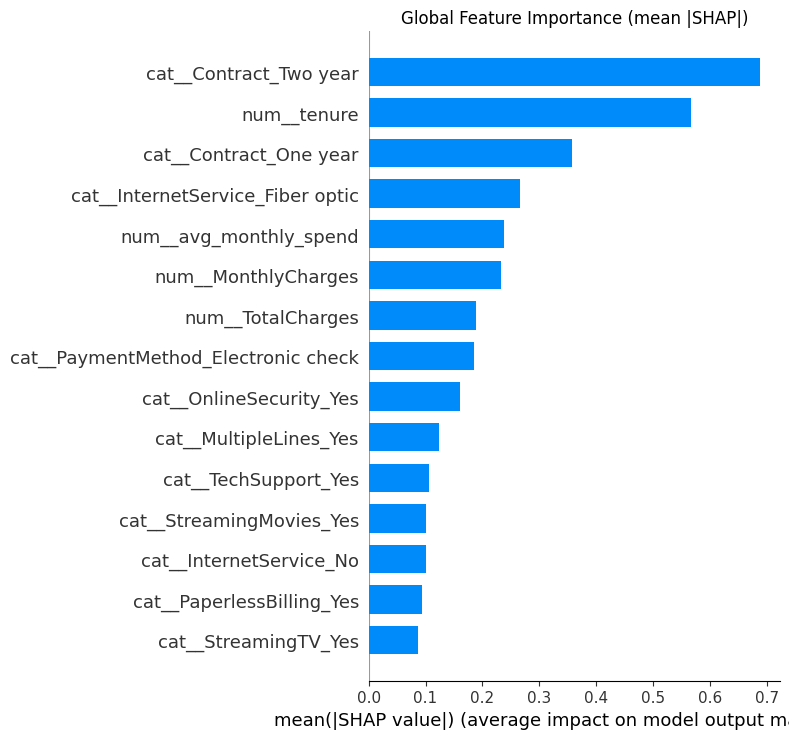

Saved: docs/shap_summary_bar.png


In [5]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Global Feature Importance (mean |SHAP|)')
plt.tight_layout()
plt.savefig('../docs/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/shap_summary_bar.png')

## Beeswarm plot (impact direction + magnitude)

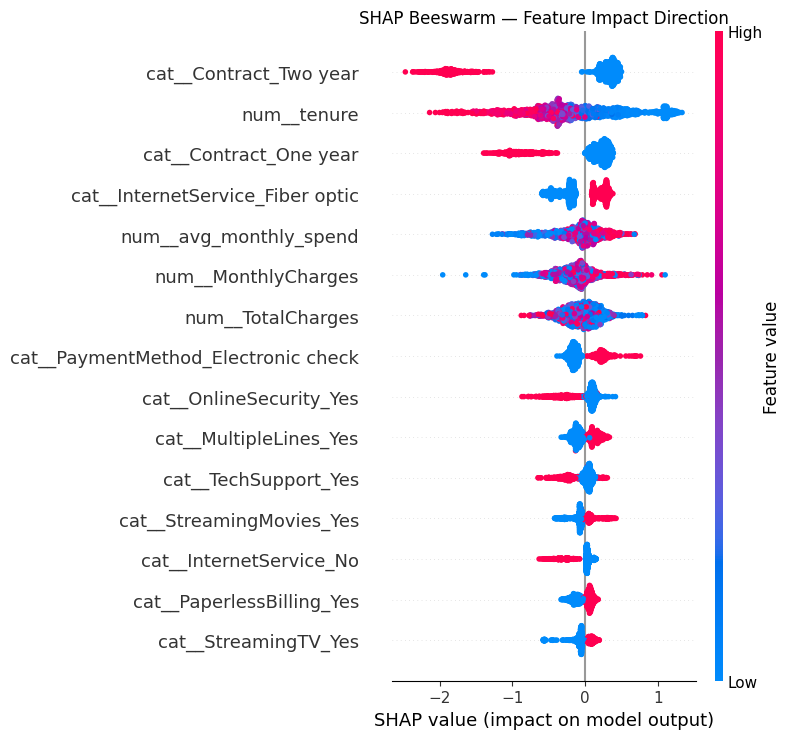

Saved: docs/shap_beeswarm.png


In [6]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.savefig('../docs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/shap_beeswarm.png')

## Pick a high-risk customer for the waterfall chart

Find a churner the model was confident about — good for the README/LinkedIn screenshot.

In [7]:
probs = pipeline.predict_proba(X_test)[:, 1]

# Find index of actual churner with highest predicted churn probability
churner_indices = np.where(y_test.values == 1)[0]
sample_idx = churner_indices[np.argmax(probs[churner_indices])]

print(f'Sample index: {sample_idx}')
print(f'Predicted churn probability: {probs[sample_idx]:.3f}')
print(f'Actual label: {y_test.values[sample_idx]}')

Sample index: 1149
Predicted churn probability: 0.976
Actual label: 1


## Waterfall chart for that customer

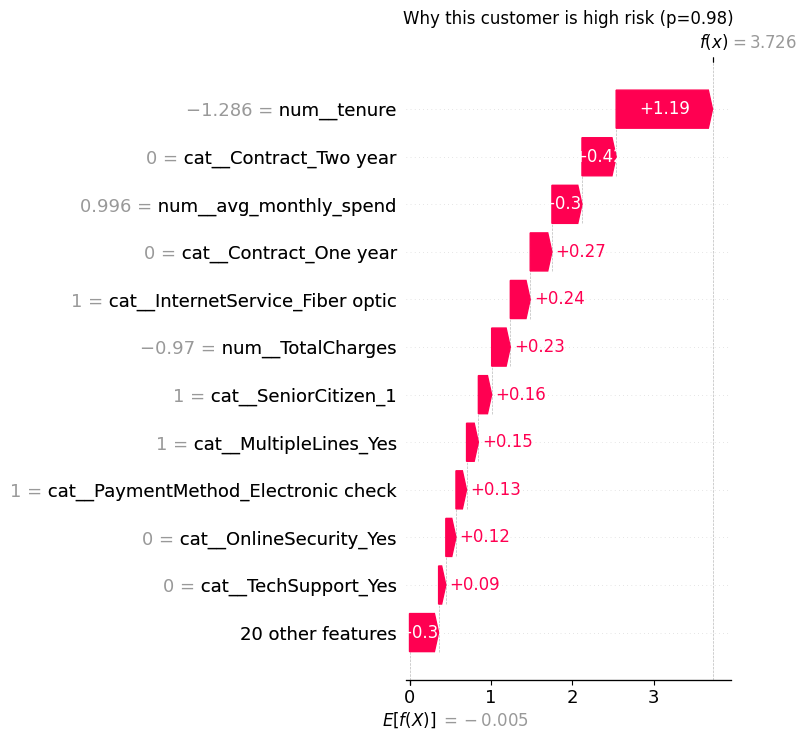

Saved: docs/shap_waterfall.png  ← use this in README + LinkedIn


In [8]:
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[sample_idx],
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f'Why this customer is high risk (p={probs[sample_idx]:.2f})')
plt.tight_layout()
plt.savefig('../docs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/shap_waterfall.png  ← use this in README + LinkedIn')

## Save explainer for Streamlit app

In [9]:
joblib.dump(explainer, '../data/models/shap_explainer.joblib')
print('Explainer saved: data/models/shap_explainer.joblib')

Explainer saved: data/models/shap_explainer.joblib
